# Expressing GLM-5.3

This notebook writes GLM-5.3, the open-weight model of Z.ai, as one algebraic expression and draws it part by part against its reference implementation in the Hugging Face `transformers` library. It then writes the number format of every value as `transformers` runs the FP8 checkpoint, derives the pass that reads the earlier tokens from caches, and writes the four forms into one interactive page. `notebooks/website/modern/validate_glm53.py` checks every fact the notebook states about the expression.

*Written by Claude Opus 5.5 (1M context) at effort 40 on 2026-09-27.*

In [1]:
import dataclasses

import notebooks.caching.CachedGLM53.derive_cached_glm53 as derive_cached_glm53
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.sota.GLM53.assemble_page_variants as assemble_page_variants
import notebooks.sota.GLM53.operator_explanations as operator_explanations
import notebooks.sota.GLM53.quantised_whole_model as quantised_whole_model
import notebooks.sota.GLM53.released_constants as released_constants
import notebooks.sota.GLM53.rotary_embedding as rotary_embedding
import notebooks.sota.GLM53.slide_causal_reads as slide_causal_reads
import notebooks.sota.GLM53.whole_model as whole_model
import notebooks.website.website_output as website_output
from IPython.display import Markdown, display
from notebooks.sota.GLM53.block_titles_and_descriptions import TEXT as text

DIAGRAMS = operator_explanations.with_explanation_tables(
    figures.DiagramSettings(
        mode=figures.DiagramMode.INLINE,
        dark_mode=notebook_diagrams.ColorMode.LIGHT,
        tape=figures.TapePresentation.ABSORBED,
        axis_sizes=figures.AxisSizes.SUBSCRIPT,
        axis_label_font_size=0.8,
        block_recycling=figures.BlockRecycling.RECYCLED,
        advanced_display=figures.AdvancedDisplay.LEGEND,
        expanded_parameters=figures.ExpandedParameters.WEIGHT_ARRAYS,
        title='GLM-5.3'))
QUANTISED_DIAGRAMS = quantised_whole_model.with_quantised_explanation_tables(
    dataclasses.replace(DIAGRAMS, clean_quantisation_labels=False))
PAGE = dataclasses.replace(
    assemble_page_variants.page_settings(figures.DiagramMode.HTML),
    page_directory=website_output.MODERN_PAGES)

figures.forget_drawn_blocks()

DECODE = slide_causal_reads.glm53_slid
DECODE_QUANTISED = slide_causal_reads.glm53_quantised_slid
CACHED = derive_cached_glm53.cached_glm53
CACHED_QUANTISED = derive_cached_glm53.cached_glm53_quantised
assigned_sizes = whole_model.released_assigned_sizes()
cached_sizes = derive_cached_glm53.cached_assigned_sizes()

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names the axes of that array with the size of each axis written as a subscript. An operator is a shape drawn across its operands and its results. A wire passes through an operator when the operator is broadcast over the axis of that wire, and a broadcast operator computes the same function separately at every index of the axis. A wire ends at an operator when the operator consumes the axis, and the function of the operator then reads every index of the axis together. A linear map of the hidden state is the same map at every token, so it is broadcast over the token axis. The rotary embedding turns every token by an angle that grows with the position of the token, so the rotation consumes the token axis.

A block is a titled box around a part of the expression, and a block whose repetition is greater than one denotes a loop. A box is drawn beside its body the first time that body appears and as the box alone afterwards, so a mechanism is explained once and referred to later, and the figures below are ordered so that each one introduces the bodies used by the next. On the interactive page, resting the pointer over a box or an operator opens an inspection box with its formula, a description and a link to the lines of the reference expressed by it.

A value computed by one layer and read by later layers travels on the tape rather than on a wire. The layer computing it ends in a drop onto a named slot, and every layer reading it begins with a grab from the same slot. GLM-5.3 has one such value, the top-2048 selection shared by the four layers of an IndexShare group, and its slot is named sel.

No size appears in the expression. Each axis carries a free symbol, and the sizes of the configuration are written onto the labels when a figure is drawn, so a formula reads with its symbols and one table binds the numbers.

| axis | size | what it indexes |
| --- | --- | --- |
| `x`, `v` | symbolic, 154880 | the token positions of the prompt, and the vocabulary |
| `m` | 6144 | the width of the residual |
| `h`, `q`, `c` | 64, 2048, 512 | the attention heads, the query low rank, and the key-value latent |
| `n`, `t`, `p`, `a` | 192, 32, $2 \lvert t \rvert$, $\lvert n \rvert + \lvert p \rvert$ | the unturned channels of a query head or a key head, the pairs of turned channels, the turned channels, and the whole head |
| `u` | 256 | the channels of a value head |
| `i`, `d`, `\bar{d}` | 32, 128, $\lvert d \rvert - \lvert p \rvert$ | the indexer heads, the width of one, and the unturned channels of an indexer vector |
| `r`, `s` | $\lvert x \rvert$, 2048 | the distance counted back from a query, and a slot of the top-2048 selection |
| `e`, `k`, `f` | 256, 8, 2048 | the routed experts, the experts kept for one token, and the width of an expert |
| `g` | 12288 | the width of the dense MLP |

Two of those axes hold a value at some of their positions and nothing at the others, and the position of the query decides which. The distance axis `r|x` counts back from a query, so distance $i_{r}$ of query $i_{x}$ holds a value when $i_{x} - i_{r} \geq 0$. The selection axis `s|x` holds a value at as many of its 2048 slots as there are tokens at or before the query. A position holding nothing holds the universal unit. Every sum, maximum and contraction ignores the unit, and every elementwise map preserves it, so causality is stated once, at the view that reads back from a query, and reaches every consumer with no mask written anywhere.

Beside each figure stands a legend with one row per named axis of the term. The axis stands on the left, the integer of its size in the middle, and on the right the code form carried by its name, which is the name of the axis in generated code.

Every constant of the reference is a named symbol in the expression as well, so no size assigned to an axis can reach a constant. The table below gives the value of each symbol in the reference and the line that sets it.

In [2]:
display(Markdown(released_constants.released_constants_table()))

| symbol | value in the reference | meaning | line |
|---|---|---|---|
| $\beta$ | $8 \times 10^{6}$ | the rotary base, `rope_theta`, which sets how slowly the slowest pair of channels turns | [config.json L211-L214](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L211-L214) |
| $\varepsilon$ | $10^{-5}$ | the number added under the square root of the RMS normalisations of the residual and of the final hidden state | [config.json L209](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L209) |
| $\varepsilon_{\mathrm{l}}$ | $10^{-6}$ | the number added under the square root of the RMS normalisations of the query low rank and of the key-value latent | [modeling_glm_moe_dsa.py L49](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L49) |
| $\varepsilon_{\mathrm{k}}$ | $10^{-6}$ | the number added to the variance in the layer normalisation of the indexer keys | [modeling_glm_moe_dsa.py L191](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L191) |
| $\varepsilon_{\mathrm{r}}$ | $10^{-20}$ | the number added to the sum of the eight kept gates before each gate is divided by that sum | [modeling_glm_moe_dsa.py L516](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L516) |
| $\gamma$ | $2.5$ | the factor `routed_scaling_factor`, which multiplies every normalised gate | [config.json L215](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L215) |

## GLM-5.3 and its reference implementation

GLM-5.3 is a decoder-only transformer of 78 layers with a residual width of 6,144 and a vocabulary of 154,880 tokens ([config.json L17](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L17), [config.json L200](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L200), [config.json L223](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L223)). Every layer attends with multi-head latent attention, whose 64 heads read keys and values expanded from one latent of 512 channels per token. Every layer attends to at most 2,048 tokens per query, chosen by a lightning indexer, which is the DeepSeek Sparse Attention of DeepSeek-V3.2 ([L309-L316](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L309-L316)). Layers 0 to 2 end in a dense MLP, and layers 3 to 77 end in a mixture of 256 routed experts, of which 8 run per token, beside one shared expert. The context runs to 1,048,576 tokens ([config.json L109](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L109)). The safetensors files hold 753 billion parameters, 751 billion of them in FP8, as counted by the Hugging Face API on 2026-09-23.

One mechanism separates the architecture from DeepSeek-V3.2, whose attention it otherwise follows. IndexShare, from [arXiv 2603.12201](https://arxiv.org/abs/2603.12201), lets one indexer serve four consecutive layers. A layer in the Full mode runs its own indexer, and each of the three layers after it runs no indexer and attends to the tokens chosen by the Full layer. The configuration lists the mode of every layer ([config.json L26-L105](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L26-L105)), and 21 of the 78 layers run an indexer.

Z.ai ships no inference code with the checkpoint. The Hugging Face `transformers` library implements the class named by the model card as a plain PyTorch forward pass, and serving frameworks such as vLLM and SGLang implement their own kernels for the same class. The notebook follows the `transformers` code, and the section *Facts left unstated by the figures* lists what a serving framework adds.

The checkpoint holds a 79th layer for multi-token prediction ([config.json L202](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L202)), which serving frameworks run as a draft model for speculative decoding. The `transformers` code skips the weights of that layer when it loads the checkpoint ([L648](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L648)), so the expression holds the 78 layers run by the reference and no draft layer.

## The rotary embedding

The rotary embedding turns part of every query and every key through an angle growing with the position of its token, so that the score of a query against a key depends on the distance between the two tokens ([L68-L122](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L68-L122), [L125-L161](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L125-L161)). GLM-5.3 turns 64 channels of every rotated vector, and the table of turns holds 32 frequencies at the base $\beta = 8 \times 10^{6}$ ([config.json L211-L214](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L211-L214)). The configuration of the checkpoint writes `head_dim: 192` ([config.json L15](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L15)), and `GlmMoeDsaConfig.__post_init__` replaces that value with `qk_rope_head_dim`, which is 64, before the table is built ([configuration L150-L152](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/configuration_glm_moe_dsa.py#L150-L152)).

Each rotation site is one box. Its body reads the turned channels two at a time as complex numbers, multiplies each by the entry of the table of turns for the position of its token and for the pair, and writes the pairs back as channels. The table is a `dst.Rotary`, drawn as a circle with RoPE written above it, and its entry at position $i_{x}$ and pair $i_{t}$ is $F[i_{x}, i_{t}] = e^{\mathrm{i}\, i_{x}\, \theta[i_{t}]}$ for the frequency $\theta[i_{t}] = \beta^{-i_{t}/\lvert t \rvert}$. The reference reads the pairs interleaved, with the first channel of a pair as the real part ([L156-L157](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L156-L157)), and `dst.PairsAsComplex` reads the same layout.

The attention turns 64 channels that have an axis of their own, $p$, because the reference projects the turned channels of a query and of a key with rows of their own and joins them to the unturned channels only after the turn ([L396](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L396), [L399](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L399), [L411](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L411)). The indexer turns the first 64 of the 128 channels of an indexer vector in place ([L226](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L226), [L229-L234](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L229-L234)), so its box cuts the channel axis $d$ into $p$ and $\bar{d}$, turns $p$, and joins the two parts back onto $d$.

The reference writes the turned pairs back as two halves, the 32 real parts followed by the 32 imaginary parts, where the box writes each pair back in place ([L159-L160](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L159-L160)). The query and the key are written back in the same order, so every score is unchanged.

The rotary embedding of the turned channels of a query head or a key, drawn as its box beside its body: the pairing of the 64 channels into 32 complex numbers, the table of turns as a circle, the product, and the unpairing.


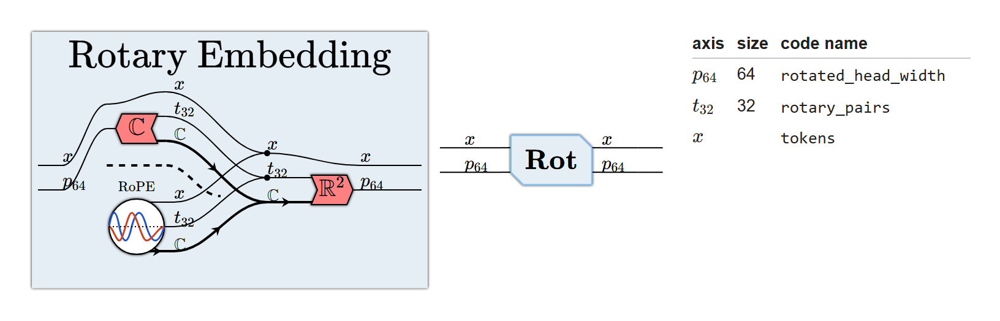

The rotary embedding of an indexer vector: the cut of the 128 channels into the 64 turned first and the 64 left alone, the turn of the first part, and the join back onto d.


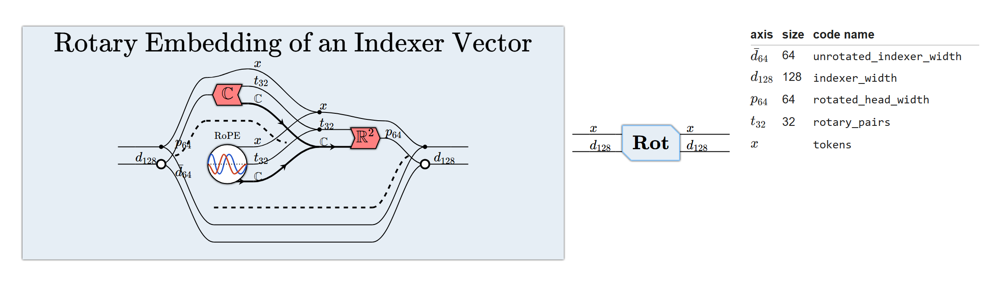

In [3]:
await figures.show(
    rotary_embedding.ROTATE_QUERY_KEY_CHANNELS,
    'The rotary embedding of the turned channels of a query head or a key, drawn as its '
    'box beside its body: the pairing of the 64 channels into 32 complex numbers, the '
    'table of turns as a circle, the product, and the unpairing.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    rotary_embedding.ROTATE_INDEXER_CHANNELS,
    'The rotary embedding of an indexer vector: the cut of the 128 channels into the 64 '
    'turned first and the 64 left alone, the turn of the first part, and the join back '
    'onto d.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## Reading back from each query

A query may read only the tokens at or before it. The expression states that with a read of the token axis. The view named Back reads an array over the tokens at token $i_{x} - i_{r}$ for every distance $i_{r}$ of every query $i_{x}$, so it returns an array over the queries and the distances counted back from each. A distance that counts back past the first token names a negative token, and a read outside an axis holds the universal unit. The distance axis therefore leaves the view as `r|x`, carrying the affine form $i_{x} - i_{r} \geq 0$ that says which distances hold a value. The reference states the same restriction as a mask of minus infinity added to the scores of the indexer ([L246-L250](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L246-L250)) and as the causal mask handed to the attention ([L708-L717](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L708-L717)).

An operation broadcast over the tokens computes the same function at every token. Reading its result at token $i_{x} - i_{r}$ therefore gives the values that reading its operand at $i_{x} - i_{r}$ and computing the operation at every query and distance gives. The figures below place every read back as early as it can stand, which is at the copy of the hidden state whose other branches read the hidden state at the query itself. The operations between that copy and the attention are then drawn over the queries and the distances. That arrangement of the expression is called the CausalSlide. It changes no value computed by the expression, because every operation passed by the read computes the same function at every token. It puts the mask beside the copy of the hidden state masked by it. The position of the read also marks the arrays that a cache of earlier tokens could hold, and the section on the pass over new tokens returns to that position.

The keys of the indexer, the keys of the attention and the values of the attention are read back through the one distance axis `r|x`. The key branch and the value branch of a layer therefore ask the latent for the same read. The read passes the copy of the latent, and one read of the hidden state serves the keys and the values.

## The lightning indexer and the top-2048 selection

A layer in the Full mode scores every token at or before each query with the lightning indexer, and a top-2048 keeps the best of them ([L164-L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L164-L253)). The indexer has 32 heads of width 128. Its query is projected from the 2,048-wide query low rank of the attention, so one intermediate feeds both projections, and the copy is drawn in the figure of the queries below. Its key is one vector of 128 channels per token, projected from the hidden state, normalised by a layer normalisation with a learned gain and bias, and shared by the 32 heads ([L189-L191](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L189-L191), [L228](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L228)). The first 64 channels of the query and of the key are turned by the rotary embedding.

Each of the 32 heads scores the query against the key. The score is multiplied by $\lvert d \rvert^{-1/2}$ and rectified, and the rectified scores are summed under a weight read off the hidden state by `weights_proj`, one number per token and head, multiplied by $\lvert i \rvert^{-1/2}$ ([L239-L244](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L239-L244)). The score of query $i_{x}$ against the token that stands $i_{r}$ places before it is

$$\mathrm{score}[i_{x}, i_{r}] = \sum_{i_{i} \in i} \lvert i \rvert^{-1/2}\, w[i_{x}, i_{i}]\, \max\Big(0,\ \lvert d \rvert^{-1/2} \sum_{i_{d} \in d} q[i_{x}, i_{i}, i_{d}]\, k[i_{x} - i_{r}, i_{d}]\Big).$$

In the figure the hidden state is read back from every query at the copy inside the indexer, because the weights of the heads read the hidden state at the query itself. The key projection, the layer normalisation and the rotation of the key then run over the queries and the distances, and the scoring box reads the keys already read back.

The top-2048 hands out the distances of the kept tokens and no score, because the reference reads the indices returned by `topk` and discards the values ([L252-L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L252-L253)). A query with fewer than 2,048 tokens at or before it keeps all of them, which is the `min` of the reference, and the selection axis `s|x` is live on as many slots as there are such tokens. The indexer scores every token at or before every query, so its cost grows with the square of the context. It runs 32 heads of 128 channels where the attention runs 64 heads of 256, and IndexShare runs it in 21 of the 78 layers.

The lightning indexer, with the body of each box beside it. The indexer query is projected from the query low rank and turned once per head. The hidden state is read back from every query at its copy, and the key is projected, normalised and turned at every query and distance. The scoring box computes one query at a time, and the top-2048 over its scores stands outside the indexer, in the attention mode.


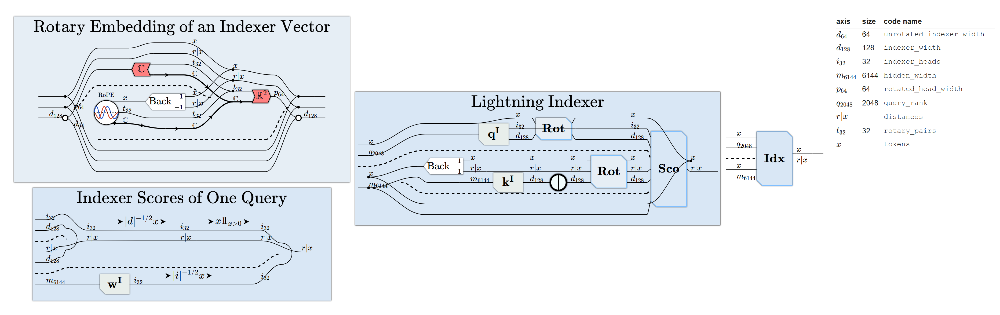

In [4]:
await figures.show(
    whole_model.part_named('Idx', DECODE),
    'The lightning indexer, with the body of each box beside it. The indexer query is '
    'projected from the query low rank and turned once per head. The hidden state is read '
    'back from every query at its copy, and the key is projected, normalised and turned '
    'at every query and distance. The scoring box computes one query at a time, and the '
    'top-2048 over its scores stands outside the indexer, in the attention mode.',
    width=1600, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The queries, the keys and the values

Multi-head latent attention computes the query of every head through a low rank and the key and the value of every head from one latent per token ([L309-L379](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L309-L379)). The query path projects the hidden state onto 2,048 channels and normalises them. One projection of that low rank gives the 192 unturned channels of each of the 64 heads, a second gives the 64 turned channels, and the two are joined into a query head of 256 channels ([L335-L337](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L335-L337), [L394-L396](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L394-L396), [L411](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L411)). The low rank is copied, and the indexer reads one copy.

The key-value path projects the hidden state onto a latent of 512 channels and normalises it, and the reference caches the normalised latent ([L398-L409](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L398-L409)). One projection of the latent gives the 192 unturned channels of the key of every head, and a second gives the 256 channels of the value of every head. A separate projection of the hidden state gives 64 channels per token. The rotary embedding turns them, and the turned channels are copied to every head, so every head of a token reads one turned key ([L362-L379](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L362-L379)). After the expansion each of the 64 heads has a key and a value of its own, which is the `num_key_value_heads` of 64 in the configuration ([config.json L201](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L201)).

The reference computes `q_b_proj`, `kv_a_proj_with_mqa` and `kv_b_proj` as one weight each, and cuts each result with `torch.split`. A linear map followed by a cut of its results is one linear map per part, so the expression holds one weight per part: $W^{Qn}$ and $W^{Qr}$ for the query, $W^{KVa}$ and $W^{Kr}$ for the latent and the turned key, and $W^{Kb}$ and $W^{Vb}$ for the expansion. The unturned and turned parts of a query and of a key are joined onto the axis $a$ of $\lvert n \rvert + \lvert p \rvert = 256$ channels, which is the `torch.cat` of the reference.

The keys and the values are drawn in the CausalSlide. The block reads the hidden state already read back from every query. Every operation in it therefore runs over the queries and the distances. The key and the value at distance $i_{r}$ of query $i_{x}$ are those of token $i_{x} - i_{r}$.

The queries: the projection onto the low rank and its RMS normalisation, the copy handed to the indexer, the unturned and turned projections of every head, the turn of the turned channels once per head, and the join onto a.


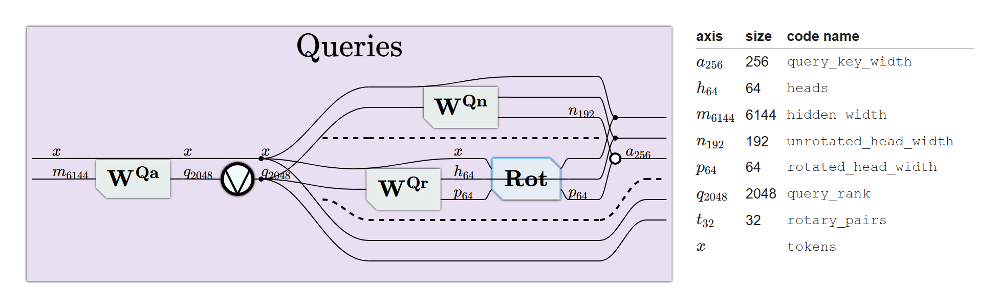

The keys and the values at every query and distance: the latent and its RMS normalisation, the expansion of the latent into the unturned key channels and the value of every head, the turned key copied to every head, and the join of the key onto a.


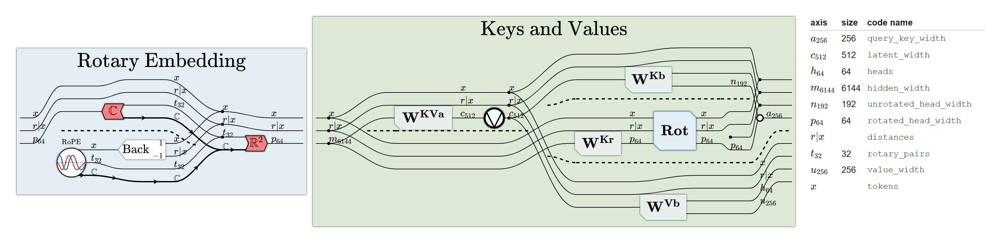

In [5]:
await figures.show(
    whole_model.part_titled(text.QUERY_TITLE, DECODE),
    'The queries: the projection onto the low rank and its RMS normalisation, the copy '
    'handed to the indexer, the unturned and turned projections of every head, the '
    'turn of the turned channels once per head, and the join onto a.',
    width=1400, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_titled(text.KEYS_AND_VALUES_TITLE, DECODE),
    'The keys and the values at every query and distance: the latent and its RMS '
    'normalisation, the expansion of the latent into the unturned key channels and the '
    'value of every head, the turned key copied to every head, and the join of the key '
    'onto a.',
    width=1400, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The attention core and the reads at the selected tokens

Every head of a query attends to the 2,048 tokens kept by the selection. The reference expands the key and the value of every token, adds minus infinity to the scores of the tokens outside the selection, and runs one softmax over every token ([L430-L443](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L430-L443), [L268-L290](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L268-L290)). A token outside the selection then takes a weight of zero, so the softmax equals the softmax over the kept tokens alone.

The expression reads the kept tokens directly. The keys of every head arrive already read back from every query, and a `dst.IndexSelect` broadcast over the queries, the heads, the slots and the channels reads the key at the distance held by each slot. The values are read the same way. The attention core is one box computed once per query and per head. The query scores against the 2,048 keys, the scores are multiplied by $\lvert a \rvert^{-1/2} = 256^{-1/2}$ ([L357](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L357)), a softmax over the slots gives the weights, and the weights sum the values of 256 channels. The output projection maps the values of the 64 heads back onto the hidden width ([L351-L355](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L351-L355), [L460-L461](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L460-L461)).

The read of the keys at the selected tokens: the gather of the key at the distance held by each slot, from the keys of every head read back from every query.


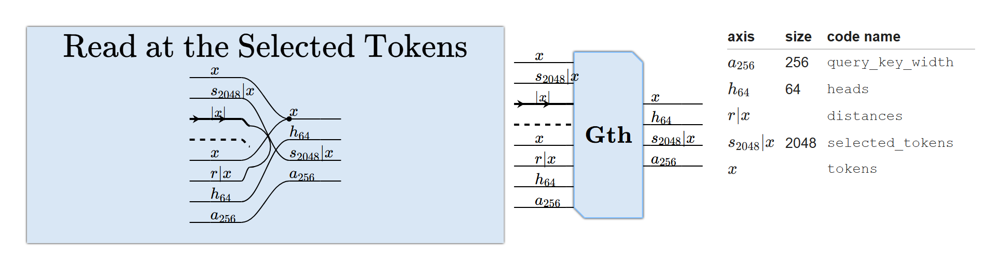

The attention core, one box computed once per query and head: the scores against the selected keys, the scale, the softmax over the selected slots and the sum of the values under it.


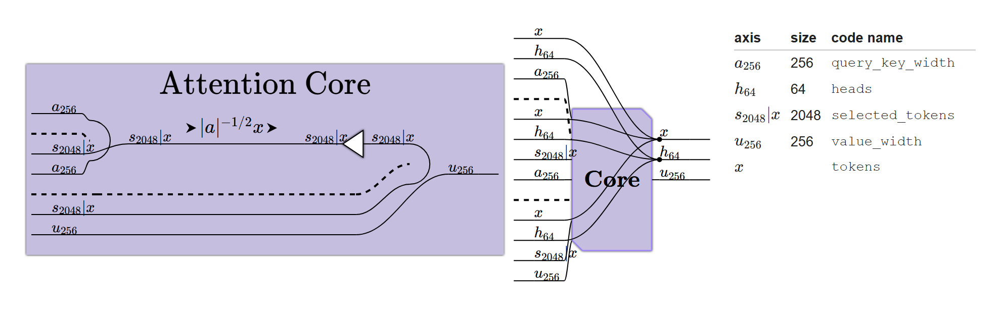

In [6]:
await figures.show(
    whole_model.part_named('Gth', DECODE),
    'The read of the keys at the selected tokens: the gather of the key at the distance '
    'held by each slot, from the keys of every head read back from every query.',
    width=1200, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('Core', DECODE),
    'The attention core, one box computed once per query and head: the scores against '
    'the selected keys, the scale, the softmax over the selected slots and the sum of '
    'the values under it.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The Full mode and the Shared mode

`config.indexer_types` gives every layer one of two modes ([config.json L26-L105](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L26-L105)). A layer in the Full mode computes its queries, keys and values, runs its own indexer and keeps its own 2,048 tokens per query. A layer in the Shared mode runs no indexer and attends to the tokens kept by the most recent Full layer ([L415-L428](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L415-L428)). The reference derives the list from an `index_topk_freq` of 4 and an `index_skip_topk_offset` of 3 ([config.json L21-L23](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L21-L23)): layer $i$ runs the Full mode when $\max(i - 2, 0)$ is a multiple of 4 ([configuration L144-L148](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/configuration_glm_moe_dsa.py#L144-L148)). Layers 0, 1 and 2 are Full, and every fourth layer after layer 2 is Full, so 21 layers run an indexer and 57 share one.

The reference passes the selection from layer to layer as `prev_topk_indices` ([L722-L733](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L722-L733)). The expression puts it on the tape. A Full layer whose selection is read by later layers ends in a drop onto the slot sel, and each Shared layer begins with a grab from sel, so every mode reads and returns the hidden state alone and a repeated block carries the residual and nothing else. Layers 0 and 1 are each followed by a Full layer, so their selections are read by no other layer and are not dropped.

In both modes the one read back from every query stands at the copy of the hidden state that feeds the queries and the keys and values. In the Full mode the indexer holds a read of its own, inside its box.

Sparse attention in the Full mode, at the head of an IndexShare group: the queries and the copy of the low rank, the hidden state read back from every query, the keys and the values at every query and distance, the indexer, the top-2048, the reads at the selected tokens, the core and the output projection. The selection is dropped onto the tape slot sel.


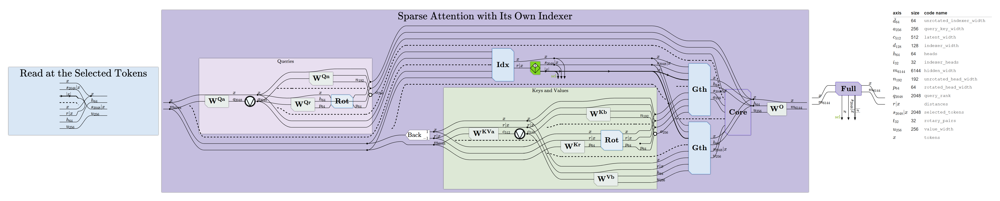

Sparse attention in the Shared mode. The selection is grabbed from the tape slot sel, and the layer computes its own queries, keys and values and runs no indexer.


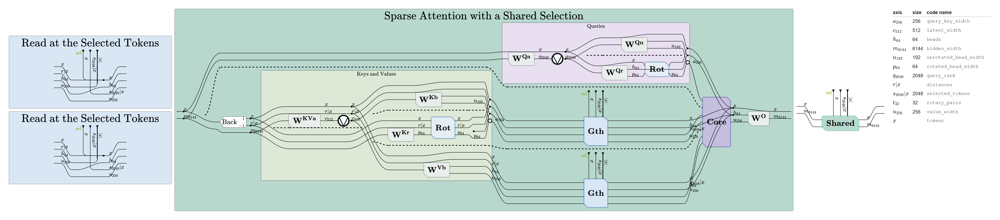

In [7]:
await figures.show(
    whole_model.part_named('Full', DECODE),
    'Sparse attention in the Full mode, at the head of an IndexShare group: the queries '
    'and the copy of the low rank, the hidden state read back from every query, the keys '
    'and the values at every query and distance, the indexer, the top-2048, the reads at '
    'the selected tokens, the core and the output projection. The selection is dropped '
    'onto the tape slot sel.',
    width=2000, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('Shared', DECODE),
    'Sparse attention in the Shared mode. The selection is grabbed from the tape slot '
    'sel, and the layer computes its own queries, keys and values and runs no indexer.',
    width=2000, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The dense MLP and the mixture of experts

The feed-forward sublayer of layers 0 to 2 is a dense SwiGLU of width 12,288, and the feed-forward sublayer of every later layer is a mixture of experts ([L592](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L592), [config.json L110-L189](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L110-L189)). A SwiGLU projects the hidden state twice, multiplies the SiLU of the first projection by the second, and projects the product back onto the hidden width ([L465-L478](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L465-L478)).

The router scores all 256 experts with a sigmoid of a linear map of the hidden state ([L494-L497](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L494-L497)). A learned correction bias is added to one copy of the scores, and the 8 experts with the largest biased scores run ([L498](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L498), [L513](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L513)). The other copy holds no bias and is read at the 8 kept experts, so the bias decides which experts run and never scales their outputs ([L514](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L514)). The 8 gates are divided by their sum plus $\varepsilon_{\mathrm{r}}$ and multiplied by the route scale $\gamma = 2.5$ ([L515-L518](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L515-L518)). The reference first restricts the choice to the best groups of experts. The configuration sets one group and keeps it ([config.json L194](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L194), [config.json L218](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L218)), so the restriction keeps every expert, and the expression leaves it out ([L499-L512](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L499-L512)).

Each routed expert is a SwiGLU of width 2,048. Its weights produce the expert axis, so the implicit weight of each projection holds all 256 experts, and a diagonalisation after the down projection keeps the output of the expert chosen at each slot. The gates multiply the outputs of the experts after the down projection, as in the reference ([L553-L557](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L553-L557)), and one contraction over the 8 slots multiplies and sums. The shared expert is a SwiGLU of width 2,048 run by every token ([L572-L574](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L572-L574)), and its output is added to the combined experts. The dense MLP and the mixture are each one box computed once per token.

The dense MLP of layers 0 to 2, one SwiGLU of width 12288 computed once per token.


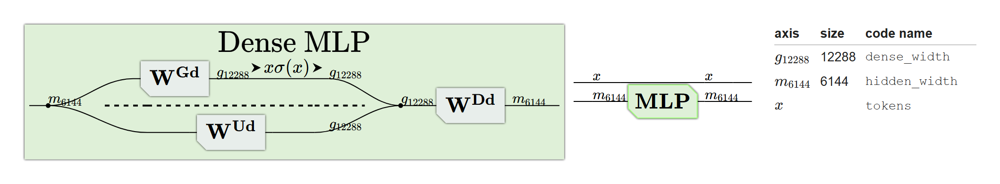

The mixture of experts of one token. The Gate box runs from the router weight to the 8 normalised gates, the correction bias is added on one copy of the scores and chooses the 8 experts, the unbiased copy is read at the experts chosen by it, each expert is a SwiGLU whose down projection is diagonalised at its own expert, and the gates land last as one contraction over the 8 live slots.


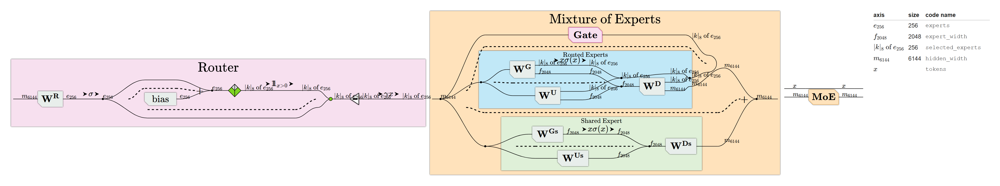

In [8]:
await figures.show(
    whole_model.part_named('MLP', DECODE),
    'The dense MLP of layers 0 to 2, one SwiGLU of width 12288 computed once per token.',
    width=1200, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('MoE', DECODE),
    'The mixture of experts of one token. The Gate box runs from the router weight to '
    'the 8 normalised gates, the correction bias is added on one copy of the scores and '
    'chooses the 8 experts, the unbiased copy is read at the experts chosen by it, each '
    'expert is a SwiGLU whose down projection is diagonalised at its own expert, and '
    'the gates land last as one contraction over the 8 live slots.',
    width=1800, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The 78 layers

Every layer is an attention sublayer and a feed-forward sublayer, each inside a pre-norm residual. The residual normalises the hidden state with an RMS normalisation, passes the result through the sublayer, and adds the output to the hidden state from before the normalisation ([L586-L627](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L586-L627)). The layer plan is written as three blocks. Layers 0 and 1 are one block at repetition two, each a Full layer with the dense MLP. Layers 2 to 5 are the first IndexShare group, written apart because layer 2 still holds the dense MLP: layer 2 drops its selection onto sel, and layers 3 to 5 are one block at repetition three that grabs it. Layers 6 to 77 are one block at repetition 18, and each iteration is a Full layer with the mixture of experts followed by three Shared layers. The repeated group carries the counter $l$, so iteration $l$ drops its selection onto member $l$ of sel and its three Shared layers grab that member. The counts add to $2 + (1 + 3) + 18 \times (1 + 3) = 78$.

The embedding looks the token identifiers up in a table of 154,880 rows of 6,144 channels ([L669](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L669), [L696-L697](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L696-L697)). After the last layer the hidden state is normalised, and the output head maps it onto a logit for every entry of the vocabulary ([L735](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L735), [L753](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L753), [L799-L802](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L799-L802)). The output head has weights of its own, because `tie_word_embeddings` is false ([config.json L217](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L217)). The reference returns the logits, and the generation configuration samples from them at a temperature of 1 with a top-p of 0.95 ([generation_config.json L9-L10](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/generation_config.json#L9-L10)).

The whole model, drawn with the body of every box left out: the embedding, layers 0 and 1 at repetition two, the first IndexShare group, the eighteen repeated IndexShare groups with the counter l, and the output logits.


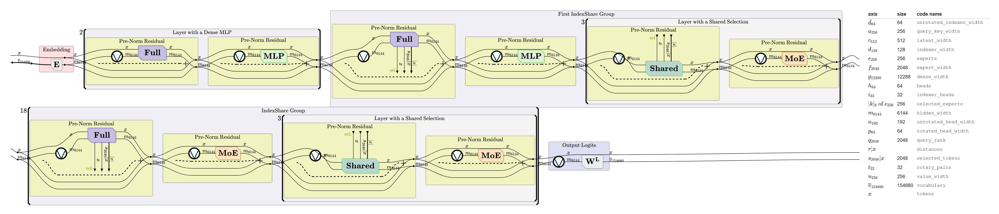

In [9]:
await figures.show(
    DECODE,
    'The whole model, drawn with the body of every box left out: the embedding, layers 0 '
    'and 1 at repetition two, the first IndexShare group, the eighteen repeated '
    'IndexShare groups with the counter l, and the output logits.',
    width=2300, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The quantised model of the FP8 checkpoint

Z.ai publishes GLM-5.3 in two checkpoints. `zai-org/GLM-5.3` holds 751 billion of its parameters in FP8 and declares how they are stored in its `quantization_config` ([config.json L224-L232](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L224-L232)). `zai-org/GLM-5.3-BF16` holds every parameter in BF16, and its configuration differs from the first only by that entry ([config.json](https://huggingface.co/zai-org/GLM-5.3-BF16/blob/9d2398f478cab2de883137db3a36ad2c96205e24/config.json)). Both were read on 2026-09-26, the first at the commit `aca966e4e027` pinned above and the second at the commit `9d2398f478ca`. The figures above state the arithmetic of both checkpoints in the reals. The model below states the number format of every value when `transformers` runs the FP8 checkpoint. This section calls such a format a quantisation, meaning the format a value is held in together with the size of that format in bits.

The configuration declares E4M3 weights, blocks of 128 by 128, a dynamic activation scheme and a list of 541 names to leave unconverted. `transformers` reads the entry into a `FineGrainedFP8Config`, whose scales are FP32 unless the entry says otherwise ([utils/quantization_config.py L1710-L1731](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/utils/quantization_config.py#L1710-L1731)). Before the weights are loaded, the quantizer replaces every `nn.Linear` with an `FP8Linear` and every block of routed experts with `FP8Experts`, except the modules the configuration lists and the modules the model names in `_keep_in_fp32_modules` ([quantizers/quantizer_finegrained_fp8.py L118-L139](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/quantizers/quantizer_finegrained_fp8.py#L118-L139), [integrations/finegrained_fp8.py L834-L916](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L834-L916)). Each replaced weight holds E4M3 elements and one FP32 scale per block of 128 rows by 128 channels, as the header of every shard states ([integrations/finegrained_fp8.py L285-L316](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L285-L316), [model-00040-of-00141.safetensors](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/model-00040-of-00141.safetensors)). The expression gives each part of `q_b_proj`, `kv_a_proj_with_mqa` and `kv_b_proj` a weight of its own. A block of 128 rows is a block of the joined weight of the reference, so a block of `q_b_proj` or `kv_b_proj` can hold rows of two parts, such as the last 64 unturned rows and the 64 turned rows of one query head. The embedding, the output head, the router, every normalisation and the correction biases are listed as unconverted ([config.json L331](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L331), [config.json L691](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L691), [config.json L293](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L293)). The configuration also lists `self_attn.indexers_proj`, which names no module of the reference ([config.json L739](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L739)). The indexer's head weights `weights_proj` stay out of FP8 because the model names them in `_keep_in_fp32_modules` ([modeling_glm_moe_dsa.py L649](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L649)). `_keep_in_fp32_modules` upcasts a module to FP32 only when the model is loaded in FP16 ([modeling_utils.py L3757-L3771](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L3757-L3771)). The model is loaded in the BF16 its configuration declares ([config.json L7](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L7), [modeling_utils.py L831-L835](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L831-L835)), so the head weights stay BF16.

An FP8 projection reads a BF16 operand and cuts the channels of each token into groups of 128. The scale of a group is its largest magnitude divided by 448, and each channel is divided by the scale and rounded to E4M3 ([integrations/finegrained_fp8.py L208-L282](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L208-L282), [deep-gemm utils/math.py L25-L37](https://huggingface.co/kernels-community/deep-gemm/blob/9590415046fa95a187af7ea03391d4782047170d/build/torch210-cxx11-cu128-x86_64-linux/utils/math.py#L25-L37), [finegrained-fp8 utils.py L433-L442](https://huggingface.co/kernels-community/finegrained-fp8/blob/3c8fcc86c0e42b7abe5bcf666d3a3afdce93a0e8/build/torch-cuda/utils.py#L433-L442)). DeepGEMM computes the rounding of a dense projection on a Hopper GPU where the `kernels` package loads it and each process holds one GPU. The Triton kernel of `kernels-community/finegrained-fp8` computes it otherwise, including a model spread over several GPUs by one process, and it computes the rounding of every routed expert, because `grouped_mm` calls no other kernel ([integrations/finegrained_fp8.py L562-L588](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L562-L588), [integrations/finegrained_fp8.py L788-L815](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L788-L815)). DeepGEMM keeps the largest magnitude of a group at or above $10^{-4}$ and multiplies each channel by the reciprocal of the scale, and the Triton kernel divides each channel by the scale. The two kernels give the same scale to every group whose largest magnitude is at least $10^{-4}$. The product accumulates in FP32, is multiplied by the scale of the operand and by the scale of the weight block, and is written in BF16 ([finegrained-fp8 matmul.py L96-L165](https://huggingface.co/kernels-community/finegrained-fp8/blob/3c8fcc86c0e42b7abe5bcf666d3a3afdce93a0e8/build/torch-cuda/matmul.py#L96-L165)). The wire in front of every FP8 projection therefore carries E4M3 with an FP32 scale per 128 channels, and the inspection box over the cast states the rounding. The two kernel repositories are pinned at the commits their branches `v2` and `v4` named on 2026-09-26, the versions `transformers` loads ([integrations/hub_kernels.py L726-L727](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/hub_kernels.py#L726-L727)).

The rest of the quantisations follow `modeling_glm_moe_dsa.py`. Every tensor passed from one module to the next is BF16. An RMS normalisation computes the normalised vector in FP32, rounds it to BF16, and multiplies it by its BF16 gain in BF16 ([modeling_glm_moe_dsa.py L57-L62](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L57-L62)). The table of turns is cast to BF16, and the turn multiplies BF16 by BF16 ([modeling_glm_moe_dsa.py L116-L122](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L116-L122), [modeling_glm_moe_dsa.py L153-L160](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L153-L160)). The indexer reads its queries and keys into FP32 before scoring. It computes the weight of each head from the hidden state with the BF16 matrix `weights_proj`, in BF16, and reads the result into FP32. It hands FP32 scores to the top-2048 ([modeling_glm_moe_dsa.py L239-L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L239-L253)). The indexer converts the kept positions to `int32`, and the positions travel on the tape to the Shared layers in `int32`. The reference reads them through `.long()` where it scatters them into the mask of the selection, and the gather at the selected tokens, which stands for the mask, reads INT64 ([modeling_glm_moe_dsa.py L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L253), [modeling_glm_moe_dsa.py L434](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L434)). The gather of a Full layer reads the INT64 positions of the top-2048 directly, where the reference converts them to `int32` and back, which changes no value. The default attention is SDPA ([modeling_utils.py L1841-L1842](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L1841-L1842)). The PyTorch release pinned here is 2.10.0 in its wheel for CUDA 12.8, the oldest release for which DeepGEMM ships a build. That wheel installs cuDNN 9.10.2.21, and PyTorch puts cuDNN attention first only above cuDNN 9.15.0 ([pytorch generate_binary_build_matrix.py L75](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/.github/scripts/generate_binary_build_matrix.py#L75), [pytorch sdp_utils.cpp L78-L116](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp#L78-L116)). PyTorch uses its flash kernel only when no mask is passed, and the reference always passes the mask of the selection, so PyTorch runs the memory-efficient kernel ([pytorch Context.h L458-L463](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/Context.h#L458-L463), [pytorch sdp_utils_cpp.h L259-L267](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/sdp_utils_cpp.h#L259-L267)). That kernel reads BF16 and keeps its scores in FP32. It rounds the exponential of each score less the largest score among the keys read so far to BF16 before the product with the values, and divides the FP32 result by the FP32 sum of the exponentials before writing BF16 ([pytorch kernel_forward.h L1285-L1293](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1285-L1293), [pytorch kernel_forward.h L925-L926](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L925-L926), [pytorch kernel_forward.h L1038-L1110](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1038-L1110)). The expression writes the softmax as one operation, so its cast to BF16 stands after the division, on the probabilities. The router reads the hidden state and its weight into FP32 and returns FP32 gates ([modeling_glm_moe_dsa.py L494-L519](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L494-L519)). The default implementation of the experts is `grouped_mm`, which casts the gates to BF16 and multiplies them into the outputs of the experts in BF16 ([modeling_utils.py L1879-L1880](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L1879-L1880), [integrations/finegrained_fp8.py L591-L606](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L591-L606)). It sums the eight products with `torch.sum`, which accumulates a BF16 tensor in FP32 and rounds the sum to BF16 once ([pytorch ReduceSumProdKernel.cu L212-L225](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/cuda/ReduceSumProdKernel.cu#L212-L225)). The eager `FP8Experts.forward` also rounds each product to BF16 and adds the eight in FP32, so the two implementations hold the same quantisations. The SiLU and the product of the two branches of every SwiGLU are BF16 ([modeling_glm_moe_dsa.py L476-L477](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L476-L477)). The output head is BF16 and returns BF16 logits ([modeling_glm_moe_dsa.py L800-L802](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L800-L802)).

The quantisations are written onto the expression by one pass. A policy names the quantisation of every weight, of every tensor passed between modules, of the scalar arithmetic inside a module, and of the rounded operand of an FP8 projection, and it names the eight boxes that depart from those defaults. The pass writes a quantisation onto every wire and puts a cast wherever an operation requires a quantisation not carried by the value. The first table below gives the policy with the lines of every entry. The second gives the quantisation of every weight, which the figure cannot label because a weight has no wire. The third counts the casts written in the expression. A body written once and composed several times counts once, so the third table counts operations of the expression and not roundings per forward pass. The expression rounds the operand of the gate and up projections of the dense MLP and of the shared expert once, where the reference calls the two projections separately and each rounds the same BF16 operand to the same E4M3 elements and scales.

The quantised figures are drawn in the CausalSlide as well. A cast is broadcast over the tokens, so the read back from every query moves past the casts as it moves past every other such operation. Taking every quantisation off the quantised model in the CausalSlide gives the model in the CausalSlide drawn above.

In [10]:
display(Markdown(quantised_whole_model.policy_table()))
display(Markdown(quantised_whole_model.weight_table()))
display(Markdown(quantised_whole_model.cast_table()))

| quantisation | what it applies to | lines |
|---|---|---|
| E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | every projection of the attention, the indexer queries and keys, the dense MLP, the shared expert and the routed experts, which the quantizer replaces with `FP8Linear` or `FP8Experts` because the configuration does not list them as unconverted. The expression splits `q_b_proj`, `kv_a_proj_with_mqa` and `kv_b_proj` into one weight per part. A block of 128 rows is a block of the joined weight of the reference, so a block of `q_b_proj` or `kv_b_proj` can hold rows of two parts | [config.json L224-L232](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L224-L232), [integrations/finegrained_fp8.py L834-L916](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L834-L916), [integrations/finegrained_fp8.py L285-L317](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L285-L317), [integrations/finegrained_fp8.py L609-L693](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L609-L693), [utils/quantization_config.py L1710-L1731](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/utils/quantization_config.py#L1710-L1731), [model-00040-of-00141.safetensors](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/model-00040-of-00141.safetensors) |
| E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 channels | the operand of an FP8 projection, rounded per token before a product in E4M3 with an FP32 accumulator. DeepGEMM rounds the operand of an `FP8Linear` on a Hopper GPU where the `kernels` package loads it and each process holds one GPU. DeepGEMM ships builds for PyTorch 2.10 and later alone, and the release pinned here is PyTorch 2.10.0. The Triton kernel rounds the operand otherwise, including a model spread over several GPUs by one process, and it rounds every operand of the routed experts, because `grouped_mm` calls no other kernel | [integrations/finegrained_fp8.py L208-L282](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L208-L282), [integrations/finegrained_fp8.py L788-L815](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L788-L815), [integrations/finegrained_fp8.py L562-L588](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L562-L588), [integrations/deepgemm.py L581-L622](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/deepgemm.py#L581-L622), [integrations/deepgemm.py L419-L444](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/deepgemm.py#L419-L444), [deep-gemm utils/math.py L25-L37](https://huggingface.co/kernels-community/deep-gemm/blob/9590415046fa95a187af7ea03391d4782047170d/build/torch210-cxx11-cu128-x86_64-linux/utils/math.py#L25-L37), [finegrained-fp8 matmul.py L96-L165](https://huggingface.co/kernels-community/finegrained-fp8/blob/3c8fcc86c0e42b7abe5bcf666d3a3afdce93a0e8/build/torch-cuda/matmul.py#L96-L165), [finegrained-fp8 utils.py L433-L442](https://huggingface.co/kernels-community/finegrained-fp8/blob/3c8fcc86c0e42b7abe5bcf666d3a3afdce93a0e8/build/torch-cuda/utils.py#L433-L442) |
| BF16, 16 bits, packed 2 to a word | every tensor passed from one module to the next, because the configuration declares `bfloat16` and the model is loaded at the dtype of its configuration: the embedding, the result of every projection and every RMS normalisation, the residual, the turned channels, the keys and values, the output of the attention and of every feed-forward map, and the logits | [config.json L7](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L7), [modeling_utils.py L4096-L4097](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L4096-L4097), [modeling_utils.py L831-L835](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L831-L835), [integrations/finegrained_fp8.py L194-L202](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L194-L202), [integrations/deepgemm.py L608](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/deepgemm.py#L608), [modeling_glm_moe_dsa.py L57-L62](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L57-L62), [modeling_glm_moe_dsa.py L621-L626](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L621-L626), [modeling_glm_moe_dsa.py L800-L802](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L800-L802) |
| FP32, 32 bits | the normalisation inside an RMS normalisation, which the module then rounds to BF16 and multiplies by its BF16 gain in BF16, the router from its linear map to the normalised gates, the indexer scores from the product of the queries and the keys to the top-2048, the attention scores and the exponentials of their softmax inside the attention kernel, and the accumulator of every FP8 product | [modeling_glm_moe_dsa.py L57-L62](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L57-L62), [modeling_glm_moe_dsa.py L494-L519](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L494-L519), [modeling_glm_moe_dsa.py L239-L244](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L239-L244), [integrations/sdpa_attention.py L158](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/sdpa_attention.py#L158), [pytorch kernel_forward.h L1285-L1293](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1285-L1293), [finegrained-fp8 matmul.py L140-L150](https://huggingface.co/kernels-community/finegrained-fp8/blob/3c8fcc86c0e42b7abe5bcf666d3a3afdce93a0e8/build/torch-cuda/matmul.py#L140-L150) |
| BF16, 16 bits, packed 2 to a word | the table of turns, computed in FP32 and cast to the BF16 of the hidden state handed to the rotary embedding, and the turn of every pair, which multiplies BF16 by BF16 | [modeling_glm_moe_dsa.py L116-L122](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L116-L122), [modeling_glm_moe_dsa.py L719-L720](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L719-L720), [modeling_glm_moe_dsa.py L153-L160](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L153-L160) |
| BF16, 16 bits, packed 2 to a word | the SiLU and the product of the gate and up branches of the dense MLP, of the shared expert and of every routed expert, and the eight gates, which the experts cast to the BF16 of their outputs before the product with them, with the default `grouped_mm` implementation of the experts. The eight products are summed by `torch.sum` over a BF16 tensor, which accumulates in FP32 and returns BF16, so the sum is rounded once, as the eager `FP8Experts.forward` rounds its FP32 buffer once | [modeling_glm_moe_dsa.py L476-L477](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L476-L477), [integrations/finegrained_fp8.py L699-L710](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L699-L710), [integrations/finegrained_fp8.py L591](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L591), [integrations/finegrained_fp8.py L604-L606](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L604-L606), [pytorch ReduceSumProdKernel.cu L212-L225](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/cuda/ReduceSumProdKernel.cu#L212-L225), [integrations/finegrained_fp8.py L712-L752](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/finegrained_fp8.py#L712-L752), [modeling_utils.py L1879-L1880](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L1879-L1880) |
| BF16, 16 bits, packed 2 to a word | the queries, keys and values read by the attention core. SDPA is the default attention of the reference, and the reference always passes it the mask of the selection, so PyTorch 2.10.0 in its wheel for CUDA 12.8 runs the memory-efficient kernel. The kernel keeps the scores in FP32, rounds the exponential of each score less the largest score among the keys read so far to BF16 before the product with the values, and divides the FP32 result by the FP32 sum of the exponentials before writing BF16. The expression writes the softmax as one operation, so its cast to BF16 stands after the division | [modeling_utils.py L1841-L1842](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L1841-L1842), [modeling_glm_moe_dsa.py L430-L458](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L430-L458), [integrations/sdpa_attention.py L158-L170](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/integrations/sdpa_attention.py#L158-L170), [pytorch generate_binary_build_matrix.py L75](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/.github/scripts/generate_binary_build_matrix.py#L75), [pytorch sdp_utils.cpp L78-L116](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp#L78-L116), [pytorch Context.h L458-L463](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/Context.h#L458-L463), [pytorch sdp_utils.cpp L781](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp#L781), [pytorch sdp_utils_cpp.h L259-L267](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/sdp_utils_cpp.h#L259-L267), [pytorch attention.cu L1615-L1617](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/attention.cu#L1615-L1617), [pytorch cutlassF.h L26-L30](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernels/cutlassF.h#L26-L30), [pytorch kernel_forward.h L1225-L1259](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1225-L1259), [pytorch kernel_forward.h L1285-L1293](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1285-L1293), [pytorch kernel_forward.h L421-L426](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L421-L426), [pytorch kernel_forward.h L925-L926](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L925-L926), [pytorch kernel_forward.h L1038-L1110](https://github.com/pytorch/pytorch/blob/449b1768410104d3ed79d3bcfe4ba1d65c7f22c0/aten/src/ATen/native/transformers/cuda/mem_eff_attention/kernel_forward.h#L1038-L1110) |
| BF16, 16 bits, packed 2 to a word | the token embedding, the output head and the indexer head weights, which stay out of FP8. The configuration lists the first two as unconverted, and the model names the third in its `_keep_in_fp32_modules`, which upcasts only for an FP16 load | [config.json L331](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L331), [config.json L691](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L691), [modeling_glm_moe_dsa.py L649](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L649), [quantizers/quantizer_finegrained_fp8.py L126-L128](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/quantizers/quantizer_finegrained_fp8.py#L126-L128), [modeling_utils.py L3757-L3771](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/modeling_utils.py#L3757-L3771), [model-00001-of-00141.safetensors](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/model-00001-of-00141.safetensors) |
| FP32, 32 bits | the router weight, BF16 in the file and read through `.type(torch.float32)`, and the correction bias, an FP32 buffer held in FP32 in the file | [modeling_glm_moe_dsa.py L492](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L492), [modeling_glm_moe_dsa.py L496](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L496), [modeling_glm_moe_dsa.py L647](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L647), [config.json L283](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L283), [config.json L293](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L293), [model-00040-of-00141.safetensors](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/model-00040-of-00141.safetensors) |
| INT64, 64 bits | the token identifiers, the positions picked by a top-k, and the positions read by the gather at the selected tokens. The reference reads the positions through `.long()` where it scatters them into the mask of the selection, which the gather stands for. The gather of a Full layer reads the INT64 positions of the top-2048, where the reference converts them to `int32` and back, which changes no value | [modeling_glm_moe_dsa.py L252-L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L252-L253), [modeling_glm_moe_dsa.py L430-L441](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L430-L441), [modeling_glm_moe_dsa.py L513](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L513) |
| INT32, 32 bits | the selection on the tape, converted by the indexer before it is returned and handed from a Full layer to the Shared layers after it | [modeling_glm_moe_dsa.py L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L253), [modeling_glm_moe_dsa.py L462](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L462), [modeling_glm_moe_dsa.py L627](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L627), [modeling_glm_moe_dsa.py L722-L733](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L722-L733) |

| weight | read quantisation | quantisation in the file |
|---|---|---|
| $E$ | BF16, 16 bits, packed 2 to a word | the same |
| $W^{Dd}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Ds}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{D}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Gd}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Gs}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{G}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{KVa}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Kb}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Kr}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{L}$ | BF16, 16 bits, packed 2 to a word | the same |
| $W^{O}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Qa}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Qn}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Qr}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{R}$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $W^{Ud}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Us}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{U}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $W^{Vb}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $\mathrm{bias}$ | FP32, 32 bits | the same |
| $k^{I}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $q^{I}$ | E4M3, 8 bits, packed 4 to a word, with one FP32 scale per 128 by 128 block | the same |
| $w^{I}$ | BF16, 16 bits, packed 2 to a word | the same |

| read | written | casts written |
|---|---|---|
| BF16 | E4M3 with FP32 per 128 | 33 |
| BF16 | FP32 | 4 |
| FP32 | BF16 | 3 |
| INT32 | INT64 | 2 |
| INT64 | INT32 | 2 |

The figures below draw the quantised boxes that depart from the default rules, each beside its body. Every wire is labelled with its quantisation, and a cast is drawn as the change of that label along the wire. The figures keep the quantisation on every wire, as declared by `clean_quantisation_labels=False` in the settings. The display otherwise takes the quantisation off a wire when every operand of the operation writing the wire carries the same quantisation.

The quantised indexer scores of one query. The queries, the keys and the weights of the heads computed by weights_proj are cast from BF16 to FP32, and the scores are computed and returned in FP32.


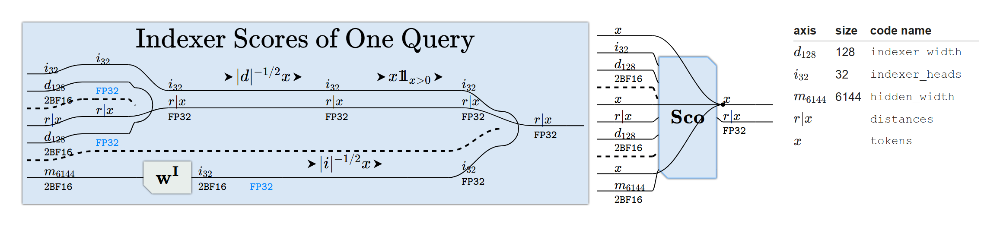

The quantised attention core of one query and head. It reads BF16, keeps the scores and the softmax in FP32, casts the probabilities to BF16 before the product with the values, and returns BF16. The memory-efficient kernel run by the reference rounds the exponentials of the scores before that product and divides by their sum after it.


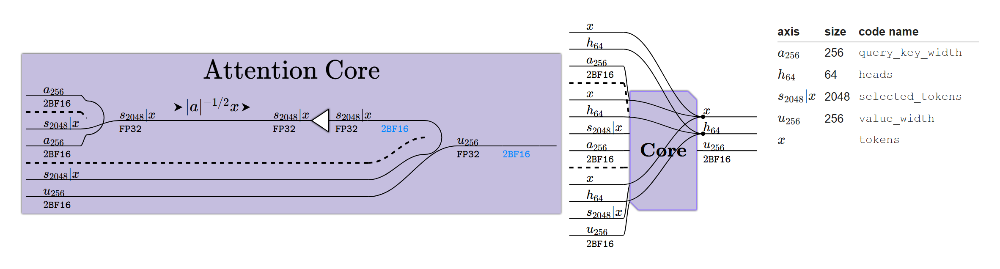

In [11]:
await figures.show(
    whole_model.part_named('Sco', DECODE_QUANTISED),
    'The quantised indexer scores of one query. The queries, the keys and the weights '
    'of the heads computed by weights_proj are cast from BF16 to FP32, and the scores '
    'are computed and returned in FP32.',
    width=1400, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=QUANTISED_DIAGRAMS)

await figures.show(
    whole_model.part_named('Core', DECODE_QUANTISED),
    'The quantised attention core of one query and head. It reads BF16, keeps the scores '
    'and the softmax in FP32, casts the probabilities to BF16 before the product with '
    'the values, and returns BF16. The memory-efficient kernel run by the reference '
    'rounds the exponentials of the scores before that product and divides by their '
    'sum after it.',
    width=1200, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=QUANTISED_DIAGRAMS)

The quantised mixture of experts of one token. The router casts the hidden state to FP32 and returns FP32 gates, the gates are cast to BF16 before they meet the experts, and every projection of an expert reads its operand rounded to E4M3 with one FP32 scale per 128 channels.


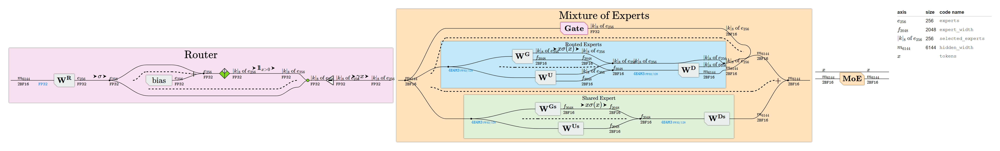

Sparse attention in the Full mode, quantised. Each FP8 projection reads its operand rounded to E4M3 with one FP32 scale per 128 channels, the indexer returns FP32 scores, and the selection is cast to INT32 before it is dropped onto the tape.




The whole quantised model, drawn with the body of every box left out. It reads the token identifiers in INT64 and returns the logits in BF16.


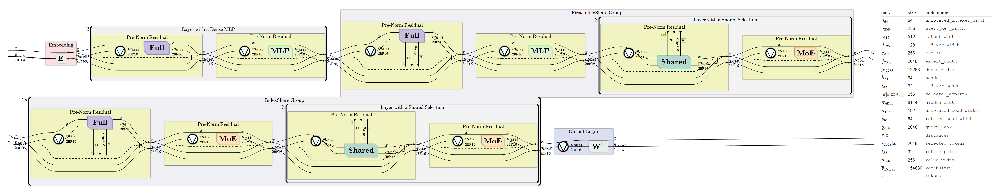

In [12]:
await figures.show(
    whole_model.part_named('MoE', DECODE_QUANTISED),
    'The quantised mixture of experts of one token. The router casts the hidden state '
    'to FP32 and returns FP32 gates, the gates are cast to BF16 before they meet the '
    'experts, and every projection of an expert reads its operand rounded to E4M3 with '
    'one FP32 scale per 128 channels.',
    width=1800, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=QUANTISED_DIAGRAMS)

await figures.show(
    whole_model.part_named('Full', DECODE_QUANTISED),
    'Sparse attention in the Full mode, quantised. Each FP8 projection reads its operand '
    'rounded to E4M3 with one FP32 scale per 128 channels, the indexer returns FP32 '
    'scores, and the selection is cast to INT32 before it is dropped onto the tape.',
    width=3200, assigned_sizes=assigned_sizes, settings=QUANTISED_DIAGRAMS)

await figures.show(
    DECODE_QUANTISED,
    'The whole quantised model, drawn with the body of every box left out. It reads the '
    'token identifiers in INT64 and returns the logits in BF16.',
    width=2600, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=assigned_sizes, settings=QUANTISED_DIAGRAMS)

## The pass over new tokens and its caches

A pass of generation reads the tokens appended since the pass before and needs the logits of those tokens alone. Write $x_{\mathrm{old}}$ for the tokens of the earlier passes and $x_{\mathrm{new}}$ for the new tokens, which are one token in plain decoding, several in a draft of speculative decoding and the whole prompt in the first pass. The pass needs the results of the model at the positions $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}}$ of the sequence. That read of the token axis is one affine map from $x_{\mathrm{new}}$ to $x$. An operation broadcast over the tokens computes its results at the new tokens from its operands read at the new tokens. The pass is therefore derived by carrying the read back from the logits through the model, and every operation passed by the read is rebuilt over $x_{\mathrm{new}}$.

A read back from every query composes with the read of the new tokens into a read of token $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}} - i_{r}$, which reaches the earlier tokens. The array read by that composite is therefore needed over the axis $x_{\mathrm{old}} + x_{\mathrm{new}}$, the earlier tokens followed by the new ones. The pass computes the array at the new tokens, and a cache supplies the earlier tokens. The operator `Caching`, drawn as a cylinder, loads the entries held by the cache for $x_{\mathrm{old}}$, appends the entries of this pass for the passes after it, and returns the array over $x_{\mathrm{old}} + x_{\mathrm{new}}$. Every wire of the pass is then a wire of the model read either at the new tokens or over $x_{\mathrm{old}} + x_{\mathrm{new}}$, and a cache stands wherever the two reads meet.

The operations computed over $x_{\mathrm{old}} + x_{\mathrm{new}}$ therefore decide what is cached. The pass below computes the expansions $W^{Kb}$ and $W^{Vb}$ of the latent, the copy of the turned key to every head and the join of the key over every cached token, as `expand_kv` of the reference does in every pass ([L362-L379](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L362-L379), [L413](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L413)). The caches then hold the normalised latent of 512 channels and the turned key of 64 channels in every layer, and the indexer key of 128 channels in every Full layer, which are the three arrays handed by the reference to its cache ([L407-L409](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L407-L409), [L236-L237](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L236-L237)). Each cache is named after the operation it follows, so the latent is cached as $c_{\mathrm{RMSNorm}}$ and both turned keys as $c_{\mathrm{Rot}}$, the indexer key inside the indexer. The table counts the values held by each layer for one token.

The selection of a Full layer travels to the Shared layers of its group on the tape slot sel within one pass. The derivation requires every grab of the slot to read the new tokens written by its drop, so the selection is not cached, and the reference does not cache it either.

A cache can stand after any operation between the copy of the hidden state and the read back from every query, because each of those operations computes the same function at every token. Moving each cache back past the operation before it reaches 104 placements of the caches of GLM-5.3. The placement drawn here holds the fewest values per token, 47,616 over the 78 layers. With every cache on the operand of the read back from every query, which holds the keys and the values of every head, the pass holds 2,558,592 values per token. A pass written by hand from `modeling_glm_moe_dsa.py`, in `notebooks/caching/CachedGLM53/`, caches the same arrays in every layer and computes the same number of operations.

| attention mode | layers | caches, with the values each holds per token | values per token of one layer |
|---|---|---|---|
| Full | 21 | $c_{Rot}$ 128, $c_{RMSNorm}$ 512, $c_{Rot}$ 64 | 704 |
| Shared | 57 | $c_{RMSNorm}$ 512, $c_{Rot}$ 64 | 576 |
| every layer | 78 | | 47,616 in all |

The body of sparse attention in the Full mode over the new tokens, with the body of every box left out. The normalised latent and the turned key are computed at the new tokens and cached, and the expansions into the keys and the values of every head run over every cached token.


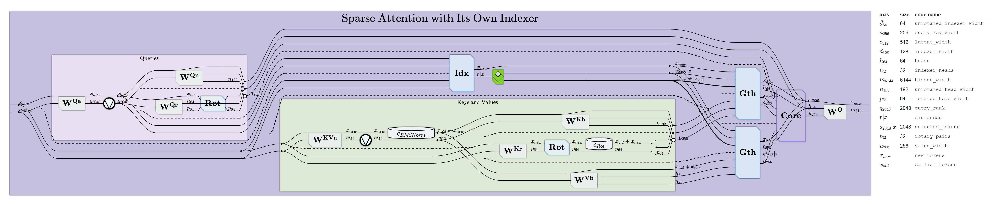

The body of the lightning indexer over the new tokens. The indexer key is computed at the new tokens and cached, and the scores of every new query read the cached keys back.


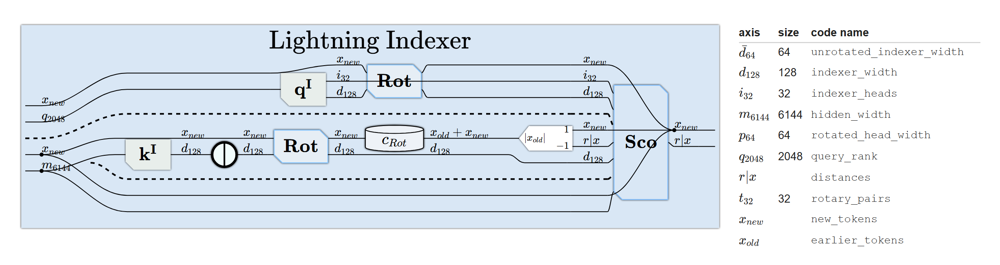

The read at the selected tokens over the new tokens. The keys of every cached token are read back from every new query, at |x_old| + i_new - i_r, and the gather reads the key at the distance held by each slot.


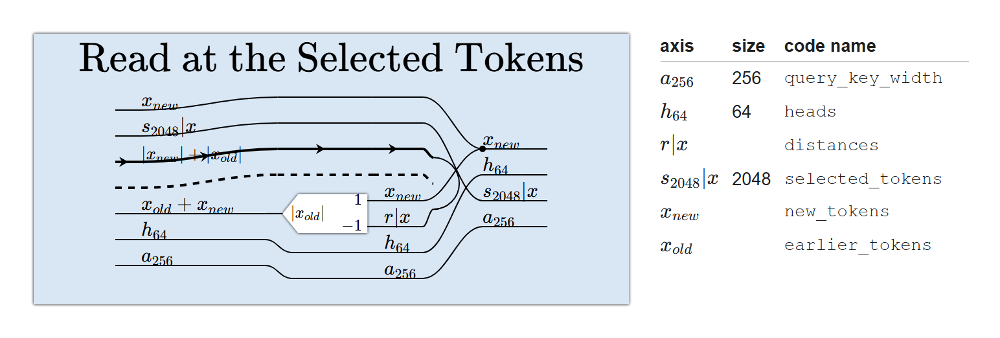

The whole pass over the new tokens, drawn with the body of every box left out. It reads the identifiers of the new tokens and returns their logits.


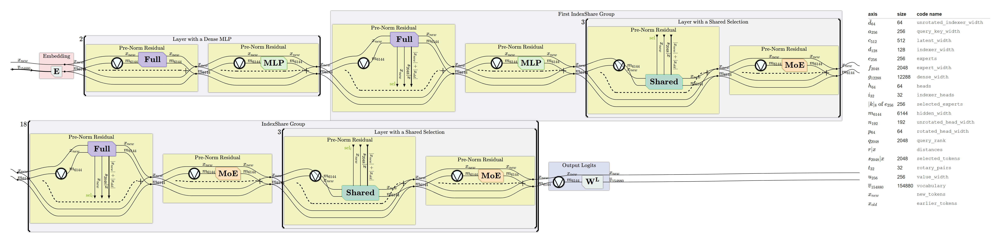

In [13]:
display(Markdown(derive_cached_glm53.cache_table()))

await figures.show(
    whole_model.part_titled(text.FULL_TITLE, CACHED),
    'The body of sparse attention in the Full mode over the new tokens, with the body of '
    'every box left out. The normalised latent and the turned key are computed at the '
    'new tokens and cached, and the expansions into the keys and the values of every '
    'head run over every cached token.',
    width=2400, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_titled(text.INDEXER_TITLE, CACHED),
    'The body of the lightning indexer over the new tokens. The indexer key is computed '
    'at the new tokens and cached, and the scores of every new query read the cached '
    'keys back.',
    width=1800, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_titled(text.GATHER_TITLE, CACHED),
    'The read at the selected tokens over the new tokens. The keys of every cached '
    'token are read back from every new query, at |x_old| + i_new - i_r, and the '
    'gather reads the key at the distance held by each slot.',
    width=1400, assigned_sizes=cached_sizes, settings=DIAGRAMS)

await figures.show(
    CACHED,
    'The whole pass over the new tokens, drawn with the body of every box left out. It '
    'reads the identifiers of the new tokens and returns their logits.',
    width=2300, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=DIAGRAMS)

## The quantised pass over new tokens

The pass over new tokens is quantised by the same policy as the model. `GlmMoeDsaModel` creates a `DynamicCache` when none is passed to it ([L699-L700](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L699-L700)), and `generate` builds the same class unless another cache implementation is requested ([generation/utils.py L2142-L2144](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/generation/utils.py#L2142-L2144)). No other implementation is requested by default ([generation/configuration_utils.py L411](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/generation/configuration_utils.py#L411)). Every layer of that cache takes the dtype of the first states handed to it and concatenates the later states in that dtype ([cache_utils.py L123-L127](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L123-L127), [cache_utils.py L143-L148](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L143-L148)), and so does the cache of the indexer keys ([cache_utils.py L348-L351](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L348-L351), [cache_utils.py L353-L366](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L353-L366)). The normalised latent, the turned key and the indexer key reach the cache in BF16, so the cache holds them in BF16. A `Caching` holds its values at the quantisation carried by its operand, and the expression states the format of the cache that way.

The rounding in front of $W^{Kb}$ and $W^{Vb}$ stands after the cache of the latent, so every cached latent is rounded to E4M3 again in every pass. `kv_b_proj` is an FP8 projection applied to the whole cache in every pass, so the reference rounds every cached latent again as well, and each rounding gives the same elements and scales. Taking every quantisation off the quantised pass gives the pass in the reals drawn above.

The body of sparse attention in the Full mode over the new tokens, quantised, with the body of every box left out. The caches hold BF16, and the latent read over every cached token is rounded to E4M3 with one FP32 scale per 128 channels in front of the two expansions.


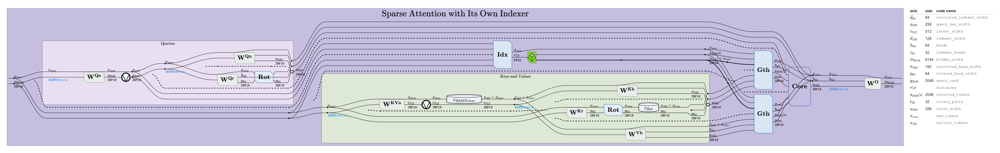

In [14]:
await figures.show(
    whole_model.part_titled(text.FULL_TITLE, CACHED_QUANTISED),
    'The body of sparse attention in the Full mode over the new tokens, quantised, with '
    'the body of every box left out. The caches hold BF16, and the latent read over '
    'every cached token is rounded to E4M3 with one FP32 scale per 128 channels in '
    'front of the two expansions.',
    width=3200, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=cached_sizes, settings=QUANTISED_DIAGRAMS)

## The four forms on one page

The last cell writes the four forms into `notebooks/website/output/modern/GLM53/index.html`, one file that opens with no server and no network. A selector above the figure switches between the model reading every token of the prompt, under Decode, and the pass over new tokens, under Cached. Each group holds the form quantised as `transformers` runs the FP8 checkpoint and the form in the reals. The page carries the two quantised forms, and it derives each form in the reals in the browser, by a functor that takes every quantisation off the term and deletes every cast between two quantisations of one value. Applied to the quantised model it gives the model in the reals, and applied to the quantised pass over new tokens it gives that pass in the reals. The page opens on the quantised model, with the legend of its axes and an inspection box over every block, operator, weight and cast. Every axis of the legend carries the name it takes in generated code.

In [15]:
await notebook_diagrams.show_page_variants(
    assemble_page_variants.page_variants(PAGE),
    'GLM-5.3 as one page: the model and the pass over new tokens, each quantised as '
    'transformers runs the FP8 checkpoint and in the reals.',
    settings=PAGE, slug=assemble_page_variants.PAGE_SLUG,
    initial=assemble_page_variants.INITIAL_VARIANT)

GLM-5.3 as one page: the model and the pass over new tokens, each quantised as transformers runs the FP8 checkpoint and in the reals.


(written to notebooks/website/output/modern/GLM53/)


## Facts left unstated by the figures

- The checkpoint stores 751 billion of its 753 billion parameters in FP8 E4M3, with one scale for each block of 128 by 128 weights, and lists 541 names to leave unconverted, among them every normalisation, the router, the embedding and the output head ([config.json L224-L232](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L224-L232)). Every wire of the figures drawn before the section *The quantised model of the FP8 checkpoint* holds reals. That section writes the number format of every value onto the expression as `transformers` runs the checkpoint.
- The checkpoint holds the multi-token prediction layer as layer 78, and the configuration sets `index_share_for_mtp_iteration` ([config.json L20](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L20)), a flag for that layer. The reference never reads the flag and skips the layer ([L648](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L648)), and the expression does not hold it.
- The reference writes the turned pairs of a rotated vector back as two halves, where `dst.Decomplex` writes each pair back in place ([L159-L160](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L159-L160)). The query and the key are permuted alike, so every score is unchanged.
- The reference restricts the choice of experts to the best groups before its top-8 ([L499-L512](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L499-L512)). With one group the restriction keeps every expert, and the expression leaves it out.
- The reference computes a score for every token and masks the scores outside the selection. The expression reads the selected tokens alone, which is the path of the FlashMLA kernel, to which the reference passes the indices ([L443-L458](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L443-L458)). The two give the same softmax, and their costs differ.
- The reference computes the indexer with no gradient ([L195](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L195)), so no gradient reaches the indexer through the selection. The expression states the forward pass alone.
- The expression holds no batch axis. The reference applies a padding mask to a batch of prompts of different lengths.

## The reference implementation

The reference is `modeling_glm_moe_dsa.py` and `configuration_glm_moe_dsa.py` in `src/transformers/models/glm_moe_dsa/` of `huggingface/transformers`, read at the commit `7cd73d9df0c1` on 2026-09-23, which was the newest commit to touch the modeling file on that date. The modeling file is generated from `modular_glm_moe_dsa.py`, and the links name the generated file, because it holds every class the model runs. The configuration of the checkpoint is the `config.json` of `zai-org/GLM-5.3` at the commit `aca966e4e027`. The same links stand in the inspection box over every block on the page.

| mechanism | here | reference | lines |
| --- | --- | --- | --- |
| Embedding and output head | `whole_model.embed`, `whole_model.output_logits` | `embed_tokens`, `norm`, `lm_head` | [L669](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L669), [L673](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L673), [L735](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L735), [L753](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L753), [L802](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L802) |
| Pre-norm residual | `layer_stack.residual_sublayer` | `GlmMoeDsaDecoderLayer` | [L586-L627](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L586-L627) |
| RMS normalisation | `ops.Normalize` | `GlmMoeDsaRMSNorm` | [L47-L65](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L47-L65) |
| Rotary embedding | `rotary_embedding` | `GlmMoeDsaRotaryEmbedding`, `apply_rotary_pos_emb_interleave` | [L68-L122](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L68-L122), [L125-L161](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L125-L161), [configuration L150-L152](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/configuration_glm_moe_dsa.py#L150-L152) |
| Lightning indexer and top-2048 | `lightning_indexer` | `GlmMoeDsaIndexer` | [L164-L253](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L164-L253) |
| Queries | `multi_latent_attention.query_path` | `q_a_proj`, `q_a_layernorm`, `q_b_proj` | [L335-L337](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L335-L337), [L394-L396](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L394-L396), [L411](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L411) |
| Keys and values | `multi_latent_attention.keys_and_values` | `kv_a_proj_with_mqa`, `kv_a_layernorm`, `kv_b_proj`, `expand_kv` | [L339-L349](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L339-L349), [L362-L379](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L362-L379), [L398-L413](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L398-L413) |
| Reads at the selected tokens and attention core | `multi_latent_attention.GATHER_KEYS`, `GATHER_VALUES`, `CORE` | the index mask and `eager_attention_forward` | [L268-L290](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L268-L290), [L357](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L357), [L430-L458](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L430-L458) |
| Output projection | `multi_latent_attention.output_projection` | `o_proj` | [L351-L355](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L351-L355), [L460-L461](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L460-L461) |
| Full and Shared modes | `attention_modes` | `indexer_types`, `prev_topk_indices` | [L358-L360](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L358-L360), [L415-L428](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L415-L428), [configuration L135-L148](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/configuration_glm_moe_dsa.py#L135-L148) |
| Layer plan | `layer_stack` | `indexer_types`, `mlp_layer_types` | [config.json L26-L105](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L26-L105), [config.json L110-L189](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L110-L189), [L722-L733](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L722-L733) |
| Dense MLP and shared expert | `feed_forward.swiglu` | `GlmMoeDsaMLP` | [L465-L478](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L465-L478), [L572-L574](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L572-L574) |
| Router | `mixture_of_experts.expert_gate` | `GlmMoeDsaTopkRouter` | [L481-L519](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L481-L519) |
| Routed experts | `mixture_of_experts.routed_experts` | `GlmMoeDsaExperts` | [L522-L559](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L522-L559) |
| Mixture of experts | `mixture_of_experts.MIXTURE` | `GlmMoeDsaMoE` | [L562-L583](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L562-L583) |
| Multi-token prediction layer, left out | none | `_keys_to_ignore_on_load_unexpected` | [L648](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L648), [config.json L202](https://huggingface.co/zai-org/GLM-5.3/blob/aca966e4e02791568aa6a4ced368624b3d897f42/config.json#L202) |
| Cache of the pass over new tokens | `derive_cached_glm53` | `DynamicCache`, `DynamicIndexedLayer`, `update`, `update_indexer`, `expand_kv` | [L699-L700](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L699-L700), [L407-L409](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L407-L409), [L236-L237](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L236-L237), [L362-L379](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/models/glm_moe_dsa/modeling_glm_moe_dsa.py#L362-L379), [cache_utils.py L123-L148](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L123-L148), [cache_utils.py L334-L366](https://github.com/huggingface/transformers/blob/7cd73d9df0c14b151c684b708a9f27d8d0349dfe/src/transformers/cache_utils.py#L334-L366) |